In [1]:
import numpy as np
import tqdm
from abc import ABC,abstractmethod
from scipy.signal import correlate2d
from numpy.lib import stride_tricks
from matplotlib import pyplot as plt
from RBF_BITMAP import rbf_bitmap
from image_feeder import read_images_from_ubyte,read_labels_from_ubyte
from IPython.display import clear_output


**正向传播**
$$
\left(
\begin{matrix}
x_{1}&x_{2}&x_{3}\\
\end{matrix}
\right)

\left(
\begin{matrix}
w_{1}&w_{4} \\
w_{2}&w_{5} \\
w_{3}&w_{6}
\end{matrix}
\right)
+
\left(
\begin{matrix}
b_{1}&b_{2}
\end{matrix}
\right
)
=
\left(
\begin{matrix}
y_{1}&y_{2}
\end{matrix}
\right)
$$
$$
\begin{align}
& Z_{i}=A_{i-1}W_{i}+b_{i} \\
& A_{i}=f(Z_{i})
\end{align}
$$


**反向传播**
$$
\begin{align}
&dZ=\Delta_{in}⊙f'(Z_{i}) \\
&dW=\frac{1}{batch} X^T \cdot dZ \\
&db=\frac{1}{batch}\sum_{i=1}^{batch}dZ_{i}
\end{align}
$$
在这里，rbf的欧氏距离惩罚即损失函数，导数是$2\cdot(A_{i-1} -W_{k})$

In [2]:
class activation(ABC):
    @abstractmethod
    def gradient(self,x)->np.ndarray:
        ...
    @abstractmethod
    def __call__(self,x)->np.ndarray:
        ...
        
class layer(ABC):
    @abstractmethod
    def forward(self,vector_input:np.ndarray)->np.ndarray:
        ...
    @abstractmethod
    def backward(self,grad_input:np.ndarray,learning_rate:float)->np.ndarray:
        ...

In [3]:
class Sigmoid(activation):
    def __call__(self, x:np.ndarray|np.matrix):
        return 1 / (1 + np.exp(-x))

    def gradient(self, x:np.ndarray|np.matrix):
        return self.__call__(x) * (1 - self.__call__(x))
        
class Tanh(activation):
    def __call__(self, x:np.ndarray|np.matrix):
        return 2 / (1 + np.exp(-2*x)) - 1

    def gradient(self, x:np.ndarray|np.matrix):
        return 1 - np.power(self.__call__(x), 2)
        
class Lecun_Tanh(activation):
    def __call__(self, x:np.ndarray|np.matrix):
        return 1.7159 * np.tanh(2/3 * x)

    def gradient(self, x:np.ndarray|np.matrix):
        return 1.14393 * (1 - np.power(np.tanh(2/3 * x), 2))

In [4]:
class Fc_layer(layer):
    m_activation_func:activation
    m_batch_size=1
    m_W:np.ndarray
    m_b:np.ndarray
    _forward_in:np.ndarray
    _forward_Z:np.ndarray #线性层输出
    _forward_A:np.ndarray #激活层输出
    m_Wshape:tuple[int,int]
    # shape(in_dim,out_dim)


    def __init__(self,in_shape:tuple[int,int,int],out_shape:tuple[int,int,int],activation_func:activation=Lecun_Tanh()):
        # shape(in_dim,out_dim)
        # TODO:改batchsize
        assert len(in_shape)==3 and len(out_shape)==3  #全部改成CNN的shape输入方式
        assert in_shape[1]==out_shape[1]==1   
        assert in_shape[2]==out_shape[2]==1   
        in_dim,_,_ = in_shape
        out_dim,_,_ = out_shape
        shape = (in_dim,out_dim)
        self.m_activation_func=activation_func
        # 立昆激活函数专用初始化
        if isinstance(activation_func,Lecun_Tanh):
            normal_scale = 1/np.sqrt(in_dim)
        else:
            normal_scale = 0.01
        self.m_W = np.random.normal(loc=0.0, scale=normal_scale, size=shape)
        self.m_b = np.random.normal(loc=0.0, scale=normal_scale, size=(1, out_dim))
        self._forward_in = np.zeros((1,in_dim))
        self._forward_Z = np.zeros_like(self.m_b)
        self._forward_A = np.zeros_like(self.m_b)
        self.m_Wshape=shape
        
    

    def forward(self,vector_input:np.ndarray)->np.ndarray:
        in_dim, out_dim = self.m_Wshape
        assert np.shape(vector_input)==(in_dim,1,1) #一定要是维度匹配的行向量
        vector_input = vector_input.reshape((1,in_dim))
        self._forward_in = vector_input
        self._forward_Z = np.matmul(vector_input,self.m_W)+ self.m_b
        self._forward_A = self.m_activation_func(self._forward_Z)
        vector_output = self._forward_A.reshape((out_dim,1,1))
        return vector_output

    def backward(self,grad_input:np.ndarray,learning_rate:float=0.01) ->np.ndarray:
        in_dim, out_dim = self.m_Wshape
        assert np.shape(grad_input)==(out_dim,1,1) #一定要是维度匹配的行向量
        grad_input = grad_input.reshape((1,out_dim))
        dZ = grad_input * self.m_activation_func.gradient(self._forward_Z)
        dW = np.matmul(self._forward_in.T,dZ) / self.m_batch_size
        db = np.sum(dZ,axis=0,keepdims=True)/ self.m_batch_size
        grad_out = np.matmul(dZ,self.m_W.T).reshape((in_dim,1,1))
        self.m_W -= learning_rate * dW
        self.m_b -= learning_rate * db
        return grad_out



In [5]:
class Rbf_layer(layer):
    input_dim = 84
    bitmap_list:np.ndarray
    _forward_in:np.ndarray
    _forward_out:np.ndarray
    def __init__(self):
        self.bitmap_list = rbf_bitmap()  #已经导入了10个rbf位图
        self._forward_in = np.zeros((1,self.input_dim))
        self._forward_out = np.zeros((1,len(self.bitmap_list)))

        
    def forward(self,vector_input:np.ndarray)->np.ndarray:
        assert vector_input.shape == (self.input_dim,1,1)
        vector_input = vector_input.reshape((1,self.input_dim))
        self._forward_in = vector_input
        # vector_input (1,84), bitmap_list (10,84)
        diff = vector_input - self.bitmap_list  #广播,爽！
        distances = np.sum(np.square(diff), axis=1)
        return np.array(distances)

    def backward(self, grad_input:np.ndarray, learning_rate: float) :
        # 为了满足该死的接口而已,grad_input输入正确的rbf参数向量标签
        assert grad_input.shape == (1, 1, 1)
        index = int(grad_input[0, 0, 0])
        return 2*(self._forward_in - self.bitmap_list[index]).reshape((self.input_dim,1,1))
         

In [6]:

f6 = Fc_layer((120,1,1),(84,1,1),activation_func=Lecun_Tanh())
output_layer = Rbf_layer()


In [7]:

x_test = np.random.normal(0, 0.1, (120,1,1))  # 输入到fc6的测试向量
target_label = 0  # 想匹配的rbf位图索引

# 简单的训练步骤
lr = 0.01
for step in range(100):
    # 前向
    fc_out = f6.forward(x_test)
    # print("fc_out shape:", fc_out.shape)
    rbf_dist = output_layer.forward(fc_out)
    # print("rbf_dist shape:", rbf_dist.shape)
    
    # 反向（从rbf层往fc层传梯度）
    rbf_grad = output_layer.backward(np.array([[[target_label]]]), learning_rate=lr)
    fc_grad = f6.backward(rbf_grad, learning_rate=lr)
    
    # 打印距离，看是不是越来越小
    if step % 10 == 0:
        print(f"Step {step}, 距离目标位图: {rbf_dist[target_label]:.4f}")


Step 0, 距离目标位图: 84.3044
Step 10, 距离目标位图: 22.8017
Step 20, 距离目标位图: 7.7743
Step 30, 距离目标位图: 3.1568
Step 40, 距离目标位图: 1.4220
Step 50, 距离目标位图: 0.6828
Step 60, 距离目标位图: 0.3417
Step 70, 距离目标位图: 0.1759
Step 80, 距离目标位图: 0.0923
Step 90, 距离目标位图: 0.0491


In [8]:
# fc_out.reshape(12,-1)
# plt.imshow(fc_out.reshape(12,-1))
# plt.imshow(rbf_bitmap()[5].reshape(12,-1))

In [9]:
np.flip(np.array([[1,2,3],[4,5,6]]))

array([[6, 5, 4],
       [3, 2, 1]])

### 卷积层

grad_out = pad(dY) 互相关 翻转后的K  
dK = X 互相关 dY  
db = sum(grad_map_in)

In [10]:
class Conv_layer(layer):
    m_kernel:np.ndarray
    m_b:np.ndarray
    m_in_shape:tuple  #(Channel_in,Height_in,Width_in)
    m_out_shape:tuple   #(Channel_out,Height_out,Width_out)
    m_kernel_shape:tuple  #(Valid_connection_number,Kernel_Height,Kernel_Width)
    m_bias_shape:tuple  #(1,Channel_out)
    m_connection_table:np.ndarray
    m_activation_func:activation
    m_connections:list[tuple[int,int,int]]  #(in_channel,out_channel,index)
    _forward_in:np.ndarray
    _forward_Z:np.ndarray

    def __init__(self,in_shape:tuple,out_shape:tuple,kernel_size:int,connection_table=None,activation_func:activation=Lecun_Tanh()):
        # 暂不支持batch size
        assert len(in_shape)==3
        assert len(out_shape)==3
        assert connection_table is None or connection_table.shape==(in_shape[0],out_shape[0])

        self.m_in_shape=in_shape
        self.m_out_shape=out_shape
        self.m_bias_shape = (1,out_shape[0])

        # 设置连接表
        if connection_table is None:
            # 全连接
            self.m_connection_table = np.ones((in_shape[0],out_shape[0]))
        else:
            self.m_connection_table = connection_table

        connection_pairs = np.argwhere(self.m_connection_table!=0)
        # 所有有效连接分配一个index给kernel, 拓展成3元组 (in_channel,out_channel,index)
        self.m_connections = [(in_c,out_c,idx) for idx,(in_c,out_c) in enumerate(connection_pairs)]
        

        valid_connection_num = np.count_nonzero(self.m_connection_table)
        self.m_kernel_shape = (valid_connection_num,kernel_size,kernel_size)

        if isinstance(activation_func, Lecun_Tanh): # Lecun激活函数建议的初始化，参考论文
            normal_scale = 1/np.sqrt(kernel_size*kernel_size*in_shape[0]/valid_connection_num)
        else:
            normal_scale = 0.01

        self.m_kernel = np.random.normal(loc=0.0, scale=normal_scale, size=self.m_kernel_shape)
        self.m_b = np.random.normal(loc=0.0, scale=normal_scale, size=self.m_bias_shape)

        self.m_activation_func = activation_func
        self._forward_in = np.zeros(self.m_in_shape)
        
    def forward(self,vector_input:np.ndarray)->np.ndarray:
        assert vector_input.shape == self.m_in_shape

        self._forward_in = vector_input
        output_maps = np.zeros(self.m_out_shape)
        for connection in self.m_connections:
            in_c, out_c, k_idx = connection
            # 对应输入通道做卷积
            input_map = vector_input[in_c]
            kernel = self.m_kernel[k_idx]
            conv_result = correlate2d(input_map, kernel, mode='valid')
            output_maps[out_c] += conv_result

        output_maps += self.m_b.reshape(-1,1,1)  # 广播加偏置
        self._forward_Z = output_maps   # 保存线性输出
        # 激活
        activated_maps = self.m_activation_func(output_maps)
        return activated_maps

    def backward(self,grad_input:np.ndarray,learning_rate:float)->np.ndarray: 
        # dY = grad_input * 激活函数在forward输出上的导数
        # grad_out = pad(dY) 互相关 翻转后的K  
        # dK = X 互相关 dY  
        # db = sum(grad_map_in)
        # 吐了，先让ai写吧
        assert grad_input.shape == self.m_out_shape
        dY = grad_input * self.m_activation_func.gradient(self._forward_Z)
        dB = np.sum(dY, axis=(1,2)) / 1  # 假设batch size=1
        dKernels = np.zeros_like(self.m_kernel)
        grad_out_maps = np.zeros(self.m_in_shape)
        for connection in self.m_connections:
            in_c, out_c, k_idx = connection
            # 计算dK
            input_map = self._forward_in[in_c]
            grad_map_in = grad_input[out_c]
            dK = correlate2d(input_map, dY[out_c], mode='valid')
            dKernels[k_idx] = dK / 1  # 假设batch size=1

            # 计算grad_out
            kernel = self.m_kernel[k_idx]
            flipped_kernel = np.flip(kernel,axis=(0,1))  # 翻转kernel
            pad_height = (kernel.shape[0] - 1) 
            pad_width = (kernel.shape[1] - 1) 
            padded_grad_map = np.pad(dY[out_c], ((pad_height, pad_height), (pad_width, pad_width)), 'constant', constant_values=0)
            grad_out_map = correlate2d(padded_grad_map, flipped_kernel, mode='valid') 
            grad_out_maps[in_c] += grad_out_map
        # 更新参数
        self.m_kernel -= learning_rate * dKernels
        self.m_b -= learning_rate * dB
        return grad_out_maps

In [11]:
# Conv_layer 小测试（随机输入 + 简单MSE下降）
conv_in_shape = (1, 8, 8)
kernel_size = 3
conv_out_shape = (1, 6, 6)  # valid卷积: 8-3+1=6
conv = Conv_layer(conv_in_shape, conv_out_shape, kernel_size)

x_conv = np.random.normal(0, 0.1, conv_in_shape)
target = np.zeros(conv_out_shape)
lr = 0.01
for step in range(50):
    out = conv.forward(x_conv)
    loss = 0.5 * np.sum((out - target) ** 2)
    grad = (out - target)
    _ = conv.backward(grad, learning_rate=lr)
    if step % 10 == 0:
        print(f"Step {step}, loss: {loss:.6f}")

Step 0, loss: 0.703675
Step 10, loss: 0.299886
Step 20, loss: 0.263581
Step 30, loss: 0.232095
Step 40, loss: 0.204775


In [12]:
# 大脑已经死机了，池化层交给ai写吧
class Pooling_layer(layer):
    m_pool_size:int
    m_stride:int
    m_in_shape: tuple # (Channel_in, Height_in, Width_in)
    m_out_shape: tuple# (Channel_out, Height_out, Width_out)（Channel_out=Channel_in）
    _forward_in: np.ndarray
    def __init__(self, in_shape:tuple, pool_size:int=2, stride:int=2):
        assert len(in_shape)==3
        self.m_in_shape = in_shape
        self.m_pool_size = pool_size
        self.m_stride = stride
        channel_in, height_in, width_in = in_shape
        height_out = (height_in - pool_size) // stride + 1
        width_out = (width_in - pool_size) // stride + 1
        self.m_out_shape = (channel_in, height_out, width_out)
        self._forward_in = np.zeros(self.m_in_shape)

    def _window_view(self, x: np.ndarray) -> np.ndarray:
        # 使用stride_tricks构造滑动窗口视图 (C, H_out, W_out, P, P)
        channel_in, height_in, width_in = x.shape
        pool = self.m_pool_size
        stride = self.m_stride
        height_out = (height_in - pool) // stride + 1
        width_out = (width_in - pool) // stride + 1
        sC, sH, sW = x.strides
        return stride_tricks.as_strided(
            x,
            shape=(channel_in, height_out, width_out, pool, pool),
            strides=(sC, sH * stride, sW * stride, sH, sW),
            writeable=False,
        )

    def forward(self, vector_input: np.ndarray) -> np.ndarray:
        assert vector_input.shape == self.m_in_shape
        self._forward_in = vector_input
        windows = self._window_view(vector_input)
        return windows.mean(axis=(3, 4))
 
    def backward(self, grad_input: np.ndarray, learning_rate: float) -> np.ndarray:
        assert grad_input.shape == self.m_out_shape
        pool = self.m_pool_size
        stride = self.m_stride
        grad_out_maps = np.zeros(self.m_in_shape, dtype=grad_input.dtype)
        scale = grad_input / (pool * pool)
        if stride == pool:
            # 非重叠窗口，安全写入
            windows = stride_tricks.as_strided(
            grad_out_maps,
            shape=(self.m_in_shape[0], self.m_out_shape[1], self.m_out_shape[2], pool, pool),
            strides=(
                grad_out_maps.strides[0],
                grad_out_maps.strides[1] * stride,
                grad_out_maps.strides[2] * stride,
                grad_out_maps.strides[1],
                grad_out_maps.strides[2],
            ),
            writeable=True,
            )
            windows += scale[..., None, None]
            return grad_out_maps

        # 有重叠时使用安全累加（仍保持接口一致）
        channel_in, height_out, width_out = grad_input.shape
        row_idx = (np.arange(height_out) * stride).reshape(height_out, 1)
        col_idx = (np.arange(width_out) * stride).reshape(1, width_out)
        for ph in range(pool):
            for pw in range(pool):
                np.add.at(
                grad_out_maps,
                (
                    np.arange(channel_in)[:, None, None],
                    row_idx[None, :, :] + ph,
                    col_idx[None, :, :] + pw,
                ),
                scale[None, :, :],
                )
        return grad_out_maps

In [13]:
## 池化层优化测试
## 罚copilot帮我写的优化
# import time

# images = read_images_from_ubyte('./dataset/train-images-idx3-ubyte')
# pool = Pooling_layer((1, 28, 28), pool_size=2, stride=2)

# n = 100
# xs = [images[i].reshape(1, 28, 28).astype(np.float32) for i in range(n)]
# np.random.seed(0)

# # 正确性验证
# max_diff_f = 0.0
# max_diff_b = 0.0
# grads = []
# for x in xs:
#     out = pool.forward(x)
#     out_better = pool.forward_better(x)
#     max_diff_f = max(max_diff_f, float(np.max(np.abs(out - out_better))))
#     g = np.random.normal(0, 1, out.shape).astype(np.float32)
#     grads.append(g)
#     b1 = pool.backward(g, learning_rate=0.01)
#     b2 = pool.backward_better(g, learning_rate=0.01)
#     max_diff_b = max(max_diff_b, float(np.max(np.abs(b1 - b2))))

# # 速度测试（forward）
# t0 = time.perf_counter()
# for x in xs:
#     _ = pool.forward(x)
# t1 = time.perf_counter()
# for x in xs:
#     _ = pool.forward_better(x)
# t2 = time.perf_counter()

# # 速度测试（backward）
# t3 = time.perf_counter()
# for g in grads:
#     _ = pool.backward(g, learning_rate=0.01)
# t4 = time.perf_counter()
# for g in grads:
#     _ = pool.backward_better(g, learning_rate=0.01)
# t5 = time.perf_counter()

# old_f_ms = (t1 - t0) * 1000
# new_f_ms = (t2 - t1) * 1000
# old_b_ms = (t4 - t3) * 1000
# new_b_ms = (t5 - t4) * 1000

# print(f"forward max diff: {max_diff_f:.6g}")
# print(f"backward max diff: {max_diff_b:.6g}")
# print(f"forward time: {old_f_ms:.2f} ms -> {new_f_ms:.2f} ms, speedup: {old_f_ms / max(new_f_ms, 1e-9):.2f}x")
# print(f"backward time: {old_b_ms:.2f} ms -> {new_b_ms:.2f} ms, speedup: {old_b_ms / max(new_b_ms, 1e-9):.2f}x")

### 连成模型！要来力！
结构图镇楼，实在不行把教父画像请过来镇楼

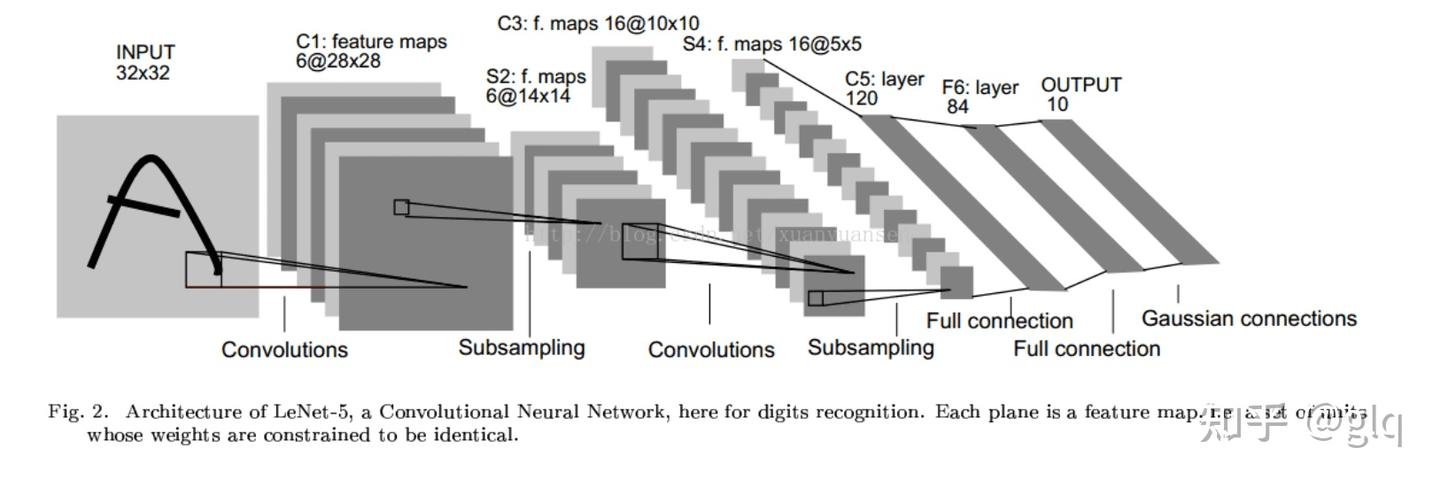

In [14]:
# 训练集
labels = read_labels_from_ubyte('./dataset/train-labels-idx1-ubyte')
images = read_images_from_ubyte('./dataset/train-images-idx3-ubyte')
# 这些图都是28x28的，padding到32x32
images = np.pad(images, ((0, 0), (2, 2), (2, 2)), 'constant', constant_values=0)
images = images.astype("float32")/127.5 - 1.0
# 测试集
test_labels = read_labels_from_ubyte('./dataset/t10k-labels-idx1-ubyte')
test_images = read_images_from_ubyte('./dataset/t10k-images-idx3-ubyte')
# 这些图也是28x28的，padding到32x32
test_images = np.pad(test_images, ((0, 0), (2, 2), (2, 2)), 'constant', constant_values=0)
test_images = test_images.astype("float32")/127.5 - 1.0


Magic Number: 2049, Number of Labels: 60000
Magic Number: 2051, Number of Images: 60000, Rows: 28, Columns: 28
Magic Number: 2049, Number of Labels: 10000
Magic Number: 2051, Number of Images: 10000, Rows: 28, Columns: 28


In [15]:
connection_table = np.array([[1,0,0,0,1,1,1,0,0,1,1,1,1,0,1,1],
                             [1,1,0,0,0,1,1,1,0,0,1,1,1,1,0,1],
                             [1,1,1,0,0,0,1,1,1,0,0,1,0,1,1,1],
                             [0,1,1,1,0,0,1,1,1,1,0,0,1,0,1,1],
                             [0,0,1,1,1,0,0,1,1,1,1,0,1,1,0,1],
                             [0,0,0,1,1,1,0,0,1,1,1,1,0,1,1,1]])
# connection_table = None

C1 = Conv_layer((1,32,32),(6,28,28),kernel_size=5)
S2 = Pooling_layer((6,28,28),pool_size=2,stride=2)
C3 = Conv_layer((6,14,14),(16,10,10),kernel_size=5,connection_table=connection_table)
S4 = Pooling_layer((16,10,10),pool_size=2,stride=2)
C5 = Conv_layer((16,5,5),(120,1,1),kernel_size=5)
f6 = Fc_layer((120,1,1),(84,1,1))
output_layer = Rbf_layer()
model = [C1,S2,C3,S4,C5,f6,output_layer]

loss_history = []
train_acc_history = []
test_acc_history = []
passed_epochs = 1


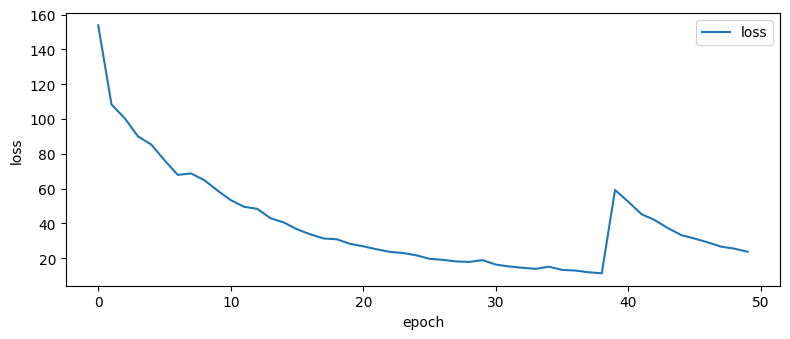

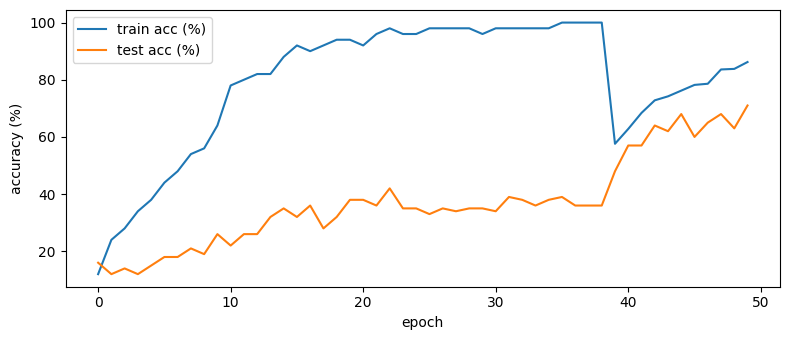

Epoch 50/50 | loss: 23.7409 | train acc: 0.8620 | test acc: 0.7100


In [35]:

# 正式训练 + 测试（单样本训练，带tqdm）
def forward_pass(model, image: np.ndarray) -> np.ndarray:
    x = np.array([image])  # (1, H, W)
    for layer in model:
        x = layer.forward(x)
    return x


def predict_label(model, image: np.ndarray) -> int:
    distances = forward_pass(model, image)
    return int(np.argmin(distances))


def train_one_epoch(model, images: np.ndarray, labels: np.ndarray|list[int], lr: float = 0.01, max_train: int | None = None):
    correct = 0
    total = 0
    epoch_loss = 0.0
    n = images.shape[0] if max_train is None else min(images.shape[0], max_train)
    for idx in tqdm.tqdm(range(n), desc="train", leave=False):
        image = images[idx]
        label = int(labels[idx])
        # 前向
        distances = forward_pass(model, image)
        loss = float(distances[label])
        epoch_loss += loss
        # 预测
        pred = int(np.argmin(distances))
        correct += int(pred == label)
        total += 1
        # 反向（RBF层只接受标签索引）
        grad = np.array([label]).reshape((1, 1, 1))
        for layer in reversed(model):
            grad = layer.backward(grad, learning_rate=lr)
    return epoch_loss / max(total, 1), correct / max(total, 1)


def evaluate(model, images: np.ndarray, labels: np.ndarray|list[int], max_test: int | None = None):
    correct = 0
    total = 0
    n = images.shape[0] if max_test is None else min(images.shape[0], max_test)
    for idx in tqdm.tqdm(range(n), desc="test", leave=False):
        image = images[idx]
        label = int(labels[idx])
        pred = predict_label(model, image)
        correct += int(pred == label)
        total += 1
    return correct / max(total, 1)


def plot_metrics(losses, train_accs, test_accs):
    clear_output(wait=True)
    plt.figure(figsize=(8, 3.5))
    plt.plot(losses, label="loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 3.5))
    plt.plot([v * 100 for v in train_accs], label="train acc (%)")
    plt.plot([v * 100 for v in test_accs], label="test acc (%)")
    plt.xlabel("epoch")
    plt.ylabel("accuracy (%)")
    plt.legend()
    plt.tight_layout()
    plt.show()


epochs = 50
 
lr = 0.0002
max_train = 500  # 先小规模跑通，改成None可全量训练
max_test = 100

%matplotlib inline
for epoch in range(passed_epochs, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, images, labels, lr=lr, max_train=max_train)
    test_acc = evaluate(model, test_images, test_labels, max_test=max_test)
    loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)
    plot_metrics(loss_history, train_acc_history, test_acc_history)
    print(f"Epoch {epoch}/{epochs} | loss: {train_loss:.4f} | train acc: {train_acc:.4f} | test acc: {test_acc:.4f}")
    passed_epochs = epoch + 1

### 小工具

In [ ]:
# 模型加载保存
import pickle
from typing import Any

def save_model(model: list, path: str) -> None:
    with open(path, "wb") as f:
        pickle.dump(model, f, protocol=pickle.HIGHEST_PROTOCOL)

def load_model(path: str) -> list:
    with open(path, "rb") as f:
        model = pickle.load(f)
    return model

# 用法示例：
# save_model(model, "./lenet5_model.pkl")
model = load_model("./lenet5_model.pkl")

In [53]:
# 手写数字识别演示（Qt5窗口 + 实时概率）
# 需要Qt后端：若无显示请先运行 %matplotlib qt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Button
from scipy.ndimage import gaussian_filter

%matplotlib qt

def _softmax_neg_dist(d: np.ndarray) -> np.ndarray:
    # d: (10,)  距离越小概率越大
    x = -d.astype(np.float64)
    x = x - np.max(x)
    ex = np.exp(x)
    return ex / np.sum(ex)

def _predict_probs(img28: np.ndarray) -> np.ndarray:
    # img28: (28,28) in [0,1]
    img32 = np.pad(img28, ((2, 2), (2, 2)), 'constant', constant_values=0)
    x = img32.astype(np.float32) * 2.0 - 1.0
    x = x.reshape(1, 32, 32)
    out = x
    for layer in model:
        out = layer.forward(out)
    d = np.array(out).reshape(-1)
    return _softmax_neg_dist(d)

class DigitDrawUI:
    def __init__(self, canvas_size=28, brush=2):
        self.canvas_size = canvas_size
        self.brush = brush
        self.canvas = np.zeros((canvas_size, canvas_size), dtype=np.float32)
        self._is_down = False

        self.fig = plt.figure(figsize=(8, 4))
        self.ax_draw = self.fig.add_subplot(1, 2, 1)
        self.ax_prob = self.fig.add_subplot(1, 2, 2)
        self.ax_draw.set_title("Draw (28x28)")
        self.ax_draw.set_xticks([])
        self.ax_draw.set_yticks([])
        self.im = self.ax_draw.imshow(self.canvas, cmap="gray", vmin=0, vmax=1, interpolation="nearest")

        self.ax_prob.set_title("RBF prob")
        self.bars = self.ax_prob.bar(range(10), np.zeros(10))
        self.ax_prob.set_ylim(0, 1)
        self.ax_prob.set_xticks(range(10))

        ax_btn = self.fig.add_axes((0.40, 0.02, 0.20, 0.08))
        self.btn = Button(ax_btn, "Clear")
        self.btn.on_clicked(self.clear)

        self.fig.canvas.mpl_connect("button_press_event", self.on_press)
        self.fig.canvas.mpl_connect("button_release_event", self.on_release)
        self.fig.canvas.mpl_connect("motion_notify_event", self.on_move)

        self.update_probs()
        plt.show()

    def clear(self, _=None):
        self.canvas.fill(0)
        self.im.set_data(self.canvas)
        self.update_probs()
        self.fig.canvas.draw_idle()

    def draw_at(self, x, y):
        if x is None or y is None:
            return
        xi = int(round(x))
        yi = int(round(y))
        r = self.brush
        x0 = max(0, xi - r)
        x1 = min(self.canvas_size, xi + r )
        y0 = max(0, yi - r)
        y1 = min(self.canvas_size, yi + r )
        self.canvas[y0:y1, x0:x1] = 1.0
        self.im.set_data(self.canvas)
        self.fig.canvas.draw_idle()
        # self.update_probs()

    def update_probs(self):

        img28 = gaussian_filter(self.canvas.astype(np.float32), sigma=0.6)
        self.fig.canvas.draw_idle()
        # img28 = self.canvas.astype(np.float32)
        self.im.set_data(img28)
        probs = _predict_probs(img28)
        for i, b in enumerate(self.bars):
            b.set_height(float(probs[i]))
        self.ax_prob.set_ylim(0, max(1e-3, float(np.max(probs)) * 1.2))

    def on_press(self, event):
        if event.inaxes != self.ax_draw:
            return
        self._is_down = True
        self.draw_at(event.xdata, event.ydata)

    def on_release(self, event):
        self.update_probs()
        self._is_down = False

    def on_move(self, event):
        if not self._is_down or event.inaxes != self.ax_draw:
            return
        self.draw_at(event.xdata, event.ydata)

# 启动演示窗口
ui = DigitDrawUI(canvas_size=28, brush=1)

qt.qpa.wayland: Wayland does not support QWindow::requestActivate()


In [17]:
vector = np.array([images[0]])
label = labels[0]
for layer in model:
    print(layer.__class__.__name__)
    # print("输入图像形状:",vector.shape)
    vector = layer.forward(vector)
print("惩罚:",vector)
# loss = 正确的rbf输出（本质上是MSE）
print("loss",vector[label])
# 反向传播
grad = np.array([label]).reshape((1,1,1))
for layer in reversed(model):
    print("反向传播:",layer.__class__.__name__)
    print("输入图像形状:",grad.shape)
    grad = layer.backward(grad, learning_rate=0.01)

Conv_layer
Pooling_layer
Conv_layer
Pooling_layer
Conv_layer
Fc_layer
Rbf_layer
惩罚: [183.31123943 179.49796949 149.32092402 169.85295044 183.61417897
 111.5385533  184.68897976 225.07635415 202.67432153 178.35227531]
loss 111.53855329791223
反向传播: Rbf_layer
输入图像形状: (1, 1, 1)
反向传播: Fc_layer
输入图像形状: (84, 1, 1)
反向传播: Conv_layer
输入图像形状: (120, 1, 1)
反向传播: Pooling_layer
输入图像形状: (16, 5, 5)
反向传播: Conv_layer
输入图像形状: (16, 10, 10)
反向传播: Pooling_layer
输入图像形状: (6, 14, 14)
反向传播: Conv_layer
输入图像形状: (6, 28, 28)


In [60]:
images[0]

array([[-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.],
       ...,
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.]], shape=(32, 32), dtype=float32)

In [51]:
%matplotlib inline
plt.imshow(images[50], cmap='gray')
# np.random.normal(loc=0.0, scale=0.01, size=(2,3,4,5))
# np.sum(np.array([[1,2,3],[4,5,6]]),axis=(0),keepdims=True)
# np.argwhere(np.array([[1,0,1],[0,1),0]])!=0)
display(test_images[114][np.where(test_images[114]!=-1)])

array([ 0.6       ,  0.9843137 ,  0.2941177 , -0.2862745 , -0.77254903,
       -0.77254903, -0.8509804 ,  0.9843137 ,  0.9764706 ,  0.9764706 ,
        0.9764706 ,  0.9843137 ,  0.9764706 ,  0.75686276, -0.654902  ,
        0.00392163,  0.9764706 ,  0.9764706 ,  0.9764706 ,  0.9843137 ,
        0.9764706 ,  0.9764706 ,  0.38823533, -0.96862745,  0.00392163,
        0.58431375,  0.18431377,  0.9843137 ,  0.9764706 ,  0.9764706 ,
        0.9764706 , -0.79607844,  0.254902  ,  0.9843137 , -0.5058824 ,
       -0.3333333 ,  0.9764706 , -0.11372548, -0.3333333 ,  0.9764706 ,
       -0.11372548, -0.3333333 ,  0.9764706 , -0.5058824 ,  0.15294123,
        0.9843137 , -0.77254903, -0.77254903, -0.77254903, -0.96862745,
       -0.8509804 , -0.5529412 ,  0.33333337,  0.32549024,  0.8352941 ,
        0.9764706 ,  0.9843137 ,  0.9764706 ,  0.9764706 ,  0.20000005,
       -0.35686272,  0.6862745 ,  0.9764706 ,  0.9843137 ,  0.9764706 ,
        0.9764706 ,  0.9764706 ,  0.9843137 ,  0.827451  ,  0.01

(28, 28)

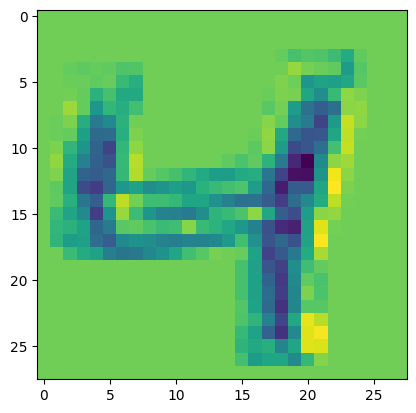

In [120]:
kernel = np.random.normal(loc=0.0, scale=0.01, size=(5,5))
padim = np.pad(images[2], ((2,2),(2,2)), 'constant', constant_values=0)
res = correlate2d(padim, kernel, mode='valid')
plt.imshow(res)
res.shape